In [ ]:
import tensorflow as tf
from tensorflow import keras
import numpy as np
import matplotlib.pyplot as plt




In [ ]:
# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Print dataset shape
print(f"Training data shape: {X_train.shape}, Labels: {y_train.shape}")
print(f"Test data shape: {X_test.shape}, Labels: {y_test.shape}")


Training data shape: (50000, 32, 32, 3), Labels: (50000, 1)
Test data shape: (10000, 32, 32, 3), Labels: (10000, 1)


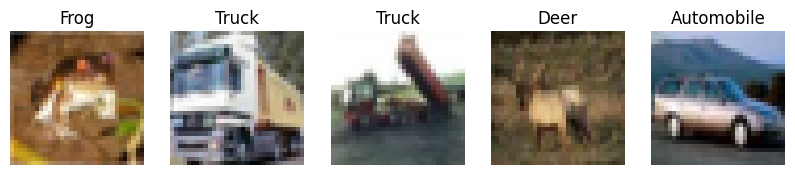

In [ ]:
# Define class names
class_names = ["Airplane", "Automobile", "Bird", "Cat", "Deer",
               "Dog", "Frog", "Horse", "Ship", "Truck"]

# Plot first 5 images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_train[i])  # Show the image (No need for cmap, it's already RGB)
    plt.title(class_names[y_train[i][0]])  # Display class name
    plt.axis('off')

plt.show()


In [ ]:
X_train = X_train.reshape(-1, 32*32*3) / 255.0  # Normalize
X_test = X_test.reshape(-1, 32*32*3) / 255.0


In [ ]:
# Define an ANN Model
model = keras.Sequential([
    keras.layers.Dense(1024, activation='relu', input_shape=(3072,)),  # Input Layer
    keras.layers.Dense(512, activation='relu'),  # Hidden Layer 1
    keras.layers.Dense(256, activation='relu'),  # Hidden Layer 2
    keras.layers.Dense(128, activation='relu'),
    keras.layers.Dense(64, activation='relu'),
    keras.layers.Dense(10, activation='softmax')  # Output Layer (10 Classes, Softmax Activation)
])

# Compile the Model
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Display Model Summary
model.summary()


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential_3"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_16 (Dense)                     │ (None, 1024)                │       3,146,752 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_17 (Dense)                     │ (None, 512)                 │         524,800 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_18 (Dense)                     │ (None, 256)                 │         131,328 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_19 (Dense)                     │ (None, 128)                 │          32,896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_20 (Dense)                     │ (None, 64)                  │           8,256 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_21 (Dense)                     │ (None, 10)                  │             650 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,844,682 (14.67 MB)

 Trainable params: 3,844,682 (14.67 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
history = model.fit(X_train, y_train, epochs=20, batch_size=64, validation_split=0.2)


Epoch 1/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 44ms/step - accuracy: 0.2341 - loss: 2.0774 - val_accuracy: 0.3457 - val_loss: 1.8168
Epoch 2/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 42ms/step - accuracy: 0.3598 - loss: 1.7713 - val_accuracy: 0.3925 - val_loss: 1.7010
Epoch 3/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 39s 39ms/step - accuracy: 0.3989 - loss: 1.6632 - val_accuracy: 0.4099 - val_loss: 1.6396
Epoch 4/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 23s 37ms/step - accuracy: 0.4245 - loss: 1.5984 - val_accuracy: 0.4251 - val_loss: 1.6102
Epoch 5/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 24s 39ms/step - accuracy: 0.4419 - loss: 1.5520 - val_accuracy: 0.4422 - val_loss: 1.5675
Epoch 6/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 25s 40ms/step - accuracy: 0.4574 - loss: 1.5066 - val_accuracy: 0.4426 - val_loss: 1.5538
Epoch 7/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 43s 43ms/step - accuracy: 0.4770 - loss: 1.4596 - val_accuracy: 0.4616 - val_loss: 1.5161
Epoch 8/20
625/625 ━━━━━━━━━━━━━━━━━━━━ 30s 47ms/step - accuracy: 0.4873 - loss: 1.4267 - 

In [ ]:
test_loss, test_acc = model.evaluate(X_test, y_test)
print(f"Test Accuracy: {test_acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.4863 - loss: 1.5285
Test Accuracy: 0.4854


In [ ]:
# Make Predictions
predictions = model.predict(X_test)

# Convert predictions to class labels
y_pred = np.argmax(predictions, axis=1)

# Flatten y_test
y_test_flat = y_test.flatten()

# Compute accuracy
from sklearn.metrics import accuracy_score
acc = accuracy_score(y_test_flat, y_pred)
print(f"Final Test Accuracy: {acc:.4f}")


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step
Final Test Accuracy: 0.4854


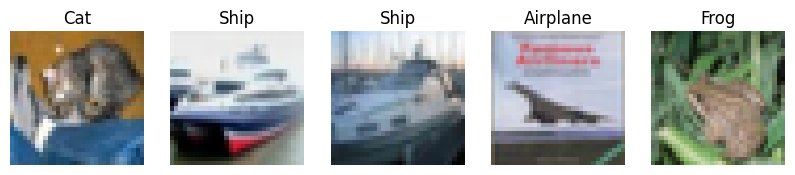

In [ ]:
# Define class names
class_names = ["Airplane", "Automobile", "Bird", "Cat", "Deer",
               "Dog", "Frog", "Horse", "Ship", "Truck"]

# Plot first 5 images
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i])  # Show the image (No need for cmap, it's already RGB)
    plt.title(class_names[y_test[i][0]])  # Display class name
    plt.axis('off')

plt.show()

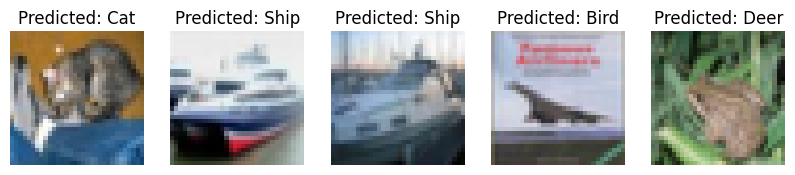

In [ ]:
plt.figure(figsize=(10, 5))
for i in range(5):
    plt.subplot(1, 5, i+1)
    plt.imshow(X_test[i].reshape(32, 32, 3))  # Reshape back to 32x32 image
    plt.title(f"Predicted: {class_names[y_pred[i]]}")
    plt.axis('off')

plt.show()


In [ ]:
from sklearn.metrics import confusion_matrix

In [ ]:
# Reshape X_test to the expected shape
X_test = X_test.reshape(-1, 32 * 32 * 3)

# Generate predictions
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
y_true_classes = np.argmax(y_test, axis=1)  # Assuming y_test is still in the original shape


313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


In [ ]:
# Compute confusion matrix
conf_matrix = confusion_matrix(y_true_classes, y_pred_classes)
print("Confusion Matrix:")
print(conf_matrix)


Confusion Matrix:
[[2258 1073  310  492  104 2029  277 1017 1610  830]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]
 [   0    0    0    0    0    0    0    0    0    0]]


NameError: name 'sns' is not defined

<Figure size 600x600 with 0 Axes>